<a href="https://colab.research.google.com/github/RamyAkin/AI-Models/blob/main/FERRASaidi_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facial Emotion Recognition using Deep Learning (ResNet18 Transfer Learning)
**CO3519 - Assessment 2**

This notebook implements a deep learning approach to facial emotion recognition using
transfer learning with ResNet18, evaluated on JAFFE and CK+ datasets for 6 emotions:
Happy, Sad, Surprise, Angry, Fear, and Neutral.

## 1. Imports and Setup

In [60]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: Tesla T4


## 2. Dataset Paths and Configuration

In [61]:
# ===================== DATASET PATHS =====================
JAFFE_TRAIN = '/content/drive/MyDrive/UniWork3rdYear/JAFFE/train'
JAFFE_TEST  = '/content/drive/MyDrive/UniWork3rdYear/JAFFE/test'

CK_TRAIN = '/content/drive/MyDrive/UniWork3rdYear/CK/train'
CK_TEST  = '/content/drive/MyDrive/UniWork3rdYear/CK/test'

# Emotion classes (same as Assignment 1)
EMOTIONS = ['Happy', 'Sad', 'Surprise', 'Angry', 'Fear', 'Neutral']
NUM_CLASSES = len(EMOTIONS)
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}
IDX_TO_EMOTION = {i: e for i, e in enumerate(EMOTIONS)}

# Training hyperparameters
IMG_SIZE = 224         # ResNet18 expects 224x224 input
BATCH_SIZE = 16        # Small batch size for small datasets
NUM_EPOCHS = 50        # Enough epochs with early stopping
LEARNING_RATE = 1e-4   # Low LR for fine-tuning pre-trained model
WEIGHT_DECAY = 1e-4    # L2 regularisation
PATIENCE = 10          # Early stopping patience

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Classes: {EMOTIONS}")

Image size: 224x224
Batch size: 16
Epochs: 50
Learning rate: 0.0001
Weight decay: 0.0001
Early stopping patience: 10
Classes: ['Happy', 'Sad', 'Surprise', 'Angry', 'Fear', 'Neutral']


## 3. Custom Dataset Class and Data Loading

In [62]:
class FERDataset(Dataset):
    """
    Custom PyTorch Dataset for Facial Emotion Recognition.
    Loads images from folder structure: root/emotion_name/image.jpg
    """
    def __init__(self, root_dir, emotions, transform=None):
        self.root_dir = root_dir
        self.emotions = emotions
        self.transform = transform
        self.images = []     # (path, label_idx)

        # Define valid image extensions to ignore system files like Thumbs.db
        valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')

        for emo in emotions:
            emo_folder = os.path.join(root_dir, emo)
            if not os.path.isdir(emo_folder):
                print(f"Warning: folder not found: {emo_folder}")
                continue
            label_idx = EMOTION_TO_IDX[emo]
            for fname in sorted(os.listdir(emo_folder)):
                # Only add if the file is a valid image type
                if fname.lower().endswith(valid_extensions):
                    fpath = os.path.join(emo_folder, fname)
                    if os.path.isfile(fpath):
                        self.images.append((fpath, label_idx))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')  # Convert to RGB for ResNet

        if self.transform:
            image = self.transform(image)

        return image, label, img_path

    def get_labels(self):
        return [label for _, label in self.images]

    def get_class_distribution(self):
        labels = self.get_labels()
        counts = Counter(labels)
        return {IDX_TO_EMOTION[k]: v for k, v in sorted(counts.items())}

print("FERDataset class updated with image file filtering.")

FERDataset class updated with image file filtering.


## 4. Data Augmentation and Transforms

We apply aggressive data augmentation to the training set to combat overfitting
on small datasets. The test set only gets resizing and normalisation.

In [63]:
# ImageNet normalisation stats (required for pre-trained ResNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms - aggressive augmentation for small datasets
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
    ),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),  # Cutout-style regularisation
])

# Test transforms - only resize and normalise
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Data augmentation transforms defined.")
print("\nTraining augmentations:")
print("  - Random horizontal flip (p=0.5)")
print("  - Random rotation (±15°)")
print("  - Random affine translation (±10%) and scale (90-110%)")
print("  - Colour jitter (brightness, contrast, saturation)")
print("  - Random grayscale (p=0.1)")
print("  - Random erasing / cutout (p=0.1)")
print("  - ImageNet normalisation")

Data augmentation transforms defined.

Training augmentations:
  - Random horizontal flip (p=0.5)
  - Random rotation (±15°)
  - Random affine translation (±10%) and scale (90-110%)
  - Colour jitter (brightness, contrast, saturation)
  - Random grayscale (p=0.1)
  - Random erasing / cutout (p=0.1)
  - ImageNet normalisation


## 5. Load Datasets and Create DataLoaders

In [64]:
def create_weighted_sampler(dataset):
    """
    Create a WeightedRandomSampler to handle class imbalance.
    Oversamples minority classes so each class is seen equally.
    """
    labels = dataset.get_labels()
    class_counts = Counter(labels)
    total = len(labels)
    class_weights = {cls: total / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in labels]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

def load_data(train_path, test_path, dataset_name):
    """
    Load train and test datasets, create DataLoaders with class balancing.
    """
    train_dataset = FERDataset(train_path, EMOTIONS, transform=train_transform)
    test_dataset  = FERDataset(test_path, EMOTIONS, transform=test_transform)

    print(f"\n=== {dataset_name} Dataset ===")
    print(f"Training samples: {len(train_dataset)}")
    print(f"Testing samples:  {len(test_dataset)}")

    train_dist = train_dataset.get_class_distribution()
    test_dist = test_dataset.get_class_distribution()
    print(f"\nTraining class distribution: {train_dist}")
    print(f"Testing class distribution:  {test_dist}")

    # Weighted sampler for class imbalance
    sampler = create_weighted_sampler(train_dataset)

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        sampler=sampler, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=2, pin_memory=True
    )

    return train_dataset, test_dataset, train_loader, test_loader

# Load JAFFE
jaffe_train_ds, jaffe_test_ds, jaffe_train_loader, jaffe_test_loader = \
    load_data(JAFFE_TRAIN, JAFFE_TEST, 'JAFFE')

# Load CK+
ck_train_ds, ck_test_ds, ck_train_loader, ck_test_loader = \
    load_data(CK_TRAIN, CK_TEST, 'CK+')


=== JAFFE Dataset ===
Training samples: 95
Testing samples:  65

Training class distribution: {'Happy': 19, 'Sad': 13, 'Surprise': 13, 'Angry': 15, 'Fear': 12, 'Neutral': 23}
Testing class distribution:  {'Happy': 11, 'Sad': 12, 'Surprise': 9, 'Angry': 10, 'Fear': 12, 'Neutral': 11}

=== CK+ Dataset ===
Training samples: 228
Testing samples:  97

Training class distribution: {'Happy': 48, 'Sad': 20, 'Surprise': 58, 'Angry': 31, 'Fear': 18, 'Neutral': 53}
Testing class distribution:  {'Happy': 21, 'Sad': 8, 'Surprise': 24, 'Angry': 14, 'Fear': 7, 'Neutral': 23}


## 6. Visualise Class Distribution

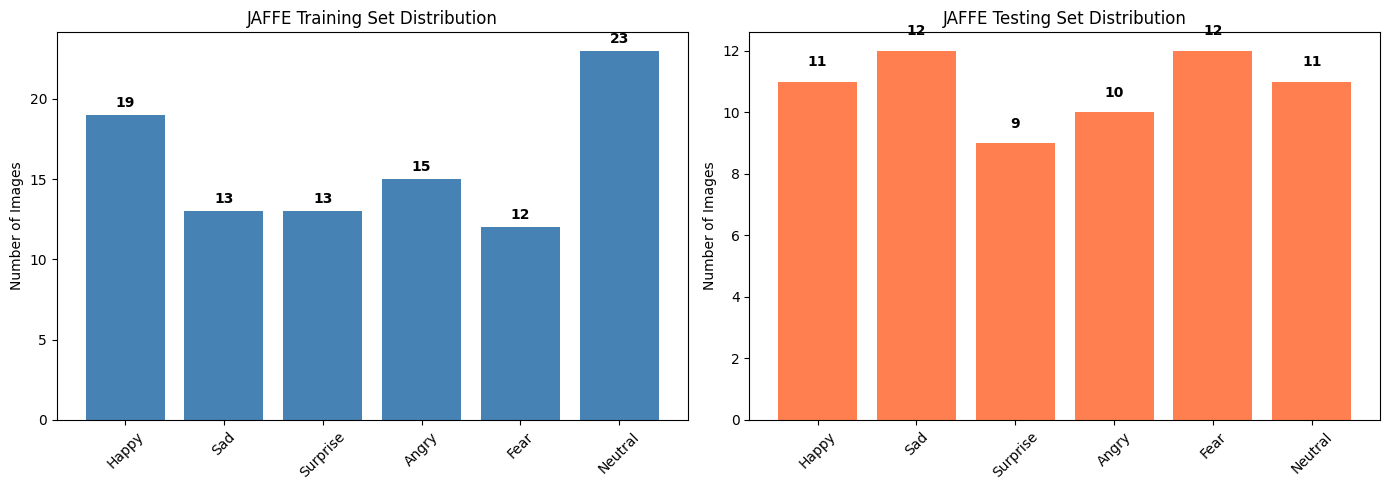

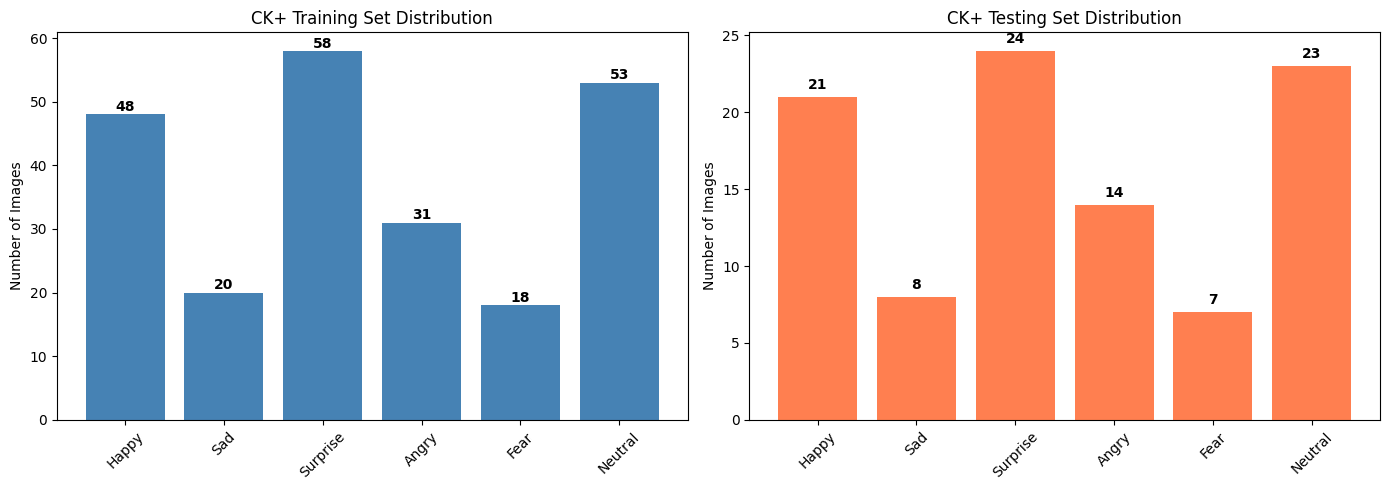

In [65]:
def plot_class_distribution(train_ds, test_ds, dataset_name):
    """Plot class distribution for train and test sets side by side."""
    train_dist = train_ds.get_class_distribution()
    test_dist = test_ds.get_class_distribution()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Training distribution
    axes[0].bar(train_dist.keys(), train_dist.values(), color='steelblue')
    axes[0].set_title(f'{dataset_name} Training Set Distribution')
    axes[0].set_ylabel('Number of Images')
    axes[0].tick_params(axis='x', rotation=45)
    for i, (k, v) in enumerate(train_dist.items()):
        axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    # Testing distribution
    axes[1].bar(test_dist.keys(), test_dist.values(), color='coral')
    axes[1].set_title(f'{dataset_name} Testing Set Distribution')
    axes[1].set_ylabel('Number of Images')
    axes[1].tick_params(axis='x', rotation=45)
    for i, (k, v) in enumerate(test_dist.items()):
        axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_class_distribution(jaffe_train_ds, jaffe_test_ds, 'JAFFE')
plot_class_distribution(ck_train_ds, ck_test_ds, 'CK+')

## 7. Model Architecture: ResNet18 with Transfer Learning

We use ResNet18 pre-trained on ImageNet as the backbone and replace the final
fully connected layer with a custom classification head for 6 emotion classes.
We freeze early layers and fine-tune later layers + our custom head.

In [66]:
def create_resnet18_model(num_classes, freeze_layers=True):
    """
    Create a ResNet18 model with transfer learning.

    Architecture modifications:
    - Pre-trained ResNet18 backbone (ImageNet weights)
    - Custom classification head with dropout for regularisation
    - Optional freezing of early convolutional layers
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_layers:
        # Freeze all layers first
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze layer3, layer4, and the final fc (fine-tune deeper layers)
        for name, param in model.named_parameters():
            if 'layer3' in name or 'layer4' in name or 'fc' in name:
                param.requires_grad = True

    # Replace the final fully connected layer
    num_features = model.fc.in_features  # 512 for ResNet18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )

    return model

# Test model creation
test_model = create_resnet18_model(NUM_CLASSES)
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\nModel Architecture: ResNet18 + Custom Classification Head")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")
print(f"Trainable ratio:      {trainable_params/total_params:.1%}")

del test_model  # Clean up


Model Architecture: ResNet18 + Custom Classification Head
Total parameters:     11,309,894
Trainable parameters: 10,626,822
Frozen parameters:    683,072
Trainable ratio:      94.0%


## 8. Training Loop with Early Stopping and Learning Rate Scheduling

In [67]:
def train_model(model, train_loader, test_loader, dataset_name,
                num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, patience=PATIENCE):
    """
    Train the model with:
    - Cross-entropy loss with label smoothing
    - AdamW optimiser with weight decay
    - Cosine annealing learning rate scheduler
    - Early stopping based on validation accuracy
    Returns training history and best model.
    """
    model = model.to(device)

    # Loss function with label smoothing (reduces overconfidence)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # AdamW optimiser (better weight decay handling than Adam)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

    # Cosine annealing scheduler for smooth LR decay
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0

    print(f"\n{'='*60}")
    print(f"Training on {dataset_name}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        # ---- Training phase ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels, _ in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # Gradient clipping for training stability
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()),
                max_norm=1.0
            )

            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation phase ----
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels, _ in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            marker = ' *** BEST ***'
        else:
            epochs_no_improve += 1
            marker = ''

        # Print progress every 5 epochs or on improvement
        if (epoch + 1) % 5 == 0 or marker:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                  f"LR: {current_lr:.6f}{marker}")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} "
                  f"(no improvement for {patience} epochs)")
            break

    # Load best model
    model.load_state_dict(best_model_state)
    print(f"\nBest validation accuracy: {best_val_acc:.4f}")

    return model, history

print("Training function defined.")

Training function defined.


## 9. Evaluation and Visualisation Functions

In [68]:
def evaluate_model(model, test_loader, dataset_name):
    """
    Comprehensive model evaluation:
    - Overall accuracy
    - Per-class precision, recall, F1-score
    - Confusion matrix
    Returns predictions for further analysis.
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_paths = []
    all_probs = []

    with torch.no_grad():
        for images, labels, paths in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Overall accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Convert to emotion names for reporting
    true_names = [IDX_TO_EMOTION[l] for l in all_labels]
    pred_names = [IDX_TO_EMOTION[p] for p in all_preds]

    print(f"\n{'='*60}")
    print(f"{dataset_name} - Model Evaluation Results")
    print(f"{'='*60}")
    print(f"\nOverall Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

    # Classification report
    print("Classification Report:")
    report = classification_report(
        true_names, pred_names,
        target_names=EMOTIONS,
        digits=4
    )
    print(report)

    # Confusion matrix
    cm = confusion_matrix(true_names, pred_names, labels=EMOTIONS)
    print("Confusion Matrix:")
    print(cm)

    return {
        'accuracy': accuracy,
        'predictions': all_preds,
        'labels': all_labels,
        'paths': all_paths,
        'probs': all_probs,
        'true_names': true_names,
        'pred_names': pred_names,
        'confusion_matrix': cm,
        'report': classification_report(
            true_names, pred_names,
            target_names=EMOTIONS,
            output_dict=True
        )
    }


def plot_training_curves(history, dataset_name):
    """
    Plot training and validation accuracy/loss curves.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss curves
    axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{dataset_name} - Training vs Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy curves
    axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
    axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{dataset_name} - Training vs Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1.05)

    # Learning rate
    axes[2].plot(epochs_range, history['lr'], 'g-', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title(f'{dataset_name} - Learning Rate Schedule')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, dataset_name):
    """
    Plot a detailed confusion matrix heatmap.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=EMOTIONS, yticklabels=EMOTIONS,
        linewidths=0.5, linecolor='gray'
    )
    plt.title(f'{dataset_name} - Confusion Matrix (ResNet18)', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def plot_per_class_f1(results, dataset_name):
    """
    Plot per-class F1-scores as a bar chart.
    """
    report = results['report']
    f1_scores = [report[e]['f1-score'] for e in EMOTIONS]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(EMOTIONS, f1_scores, color='steelblue', edgecolor='navy')
    plt.ylim(0, 1.05)
    plt.ylabel('F1-Score', fontsize=12)
    plt.title(f'{dataset_name} - Per-Class F1-Scores (ResNet18)', fontsize=14)
    plt.xticks(rotation=45, ha='right')

    for bar, score in zip(bars, f1_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{score:.2f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()


def show_classified_faces(results, test_dataset, target_emotions, dataset_name):
    """
    Display three correctly classified face examples.
    """
    selected = {}
    for i, (true, pred) in enumerate(zip(results['true_names'], results['pred_names'])):
        if true == pred and true in target_emotions and true not in selected:
            # Load raw image for display
            img = Image.open(results['paths'][i]).convert('L')
            conf = results['probs'][i][EMOTION_TO_IDX[true]]
            selected[true] = (img, pred, conf)
        if len(selected) == len(target_emotions):
            break

    if not selected:
        print(f"No correctly classified examples found for {target_emotions}")
        return

    fig, axes = plt.subplots(1, len(selected), figsize=(4 * len(selected), 4))
    if len(selected) == 1:
        axes = [axes]

    for ax, emo in zip(axes, selected.keys()):
        img, pred, conf = selected[emo]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {emo}\nPred: {pred}\nConf: {conf:.2f}', fontsize=11)
        ax.axis('off')

    plt.suptitle(f'{dataset_name} - Correctly Classified Examples', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


print("Evaluation and visualisation functions defined.")

Evaluation and visualisation functions defined.


## 10. Train and Evaluate on JAFFE Dataset

In [69]:
# Create fresh model for JAFFE
jaffe_model = create_resnet18_model(NUM_CLASSES, freeze_layers=True)

# Train
jaffe_model, jaffe_history = train_model(
    jaffe_model, jaffe_train_loader, jaffe_test_loader,
    dataset_name='JAFFE'
)


Training on JAFFE
Epoch [  1/50] Train Loss: 2.0124 | Train Acc: 0.1789 | Val Loss: 1.7983 | Val Acc: 0.2462 | LR: 0.000100 *** BEST ***
Epoch [  2/50] Train Loss: 1.7616 | Train Acc: 0.3263 | Val Loss: 1.7748 | Val Acc: 0.3231 | LR: 0.000100 *** BEST ***
Epoch [  5/50] Train Loss: 1.7214 | Train Acc: 0.3263 | Val Loss: 1.6495 | Val Acc: 0.3231 | LR: 0.000098
Epoch [  7/50] Train Loss: 1.5406 | Train Acc: 0.3895 | Val Loss: 1.5160 | Val Acc: 0.3538 | LR: 0.000097 *** BEST ***
Epoch [  8/50] Train Loss: 1.4713 | Train Acc: 0.4842 | Val Loss: 1.4416 | Val Acc: 0.3692 | LR: 0.000095 *** BEST ***
Epoch [  9/50] Train Loss: 1.4346 | Train Acc: 0.4421 | Val Loss: 1.3700 | Val Acc: 0.4462 | LR: 0.000094 *** BEST ***
Epoch [ 10/50] Train Loss: 1.2957 | Train Acc: 0.5789 | Val Loss: 1.2980 | Val Acc: 0.5231 | LR: 0.000092 *** BEST ***
Epoch [ 12/50] Train Loss: 1.1877 | Train Acc: 0.6000 | Val Loss: 1.2057 | Val Acc: 0.5538 | LR: 0.000089 *** BEST ***
Epoch [ 14/50] Train Loss: 1.2855 | Train 

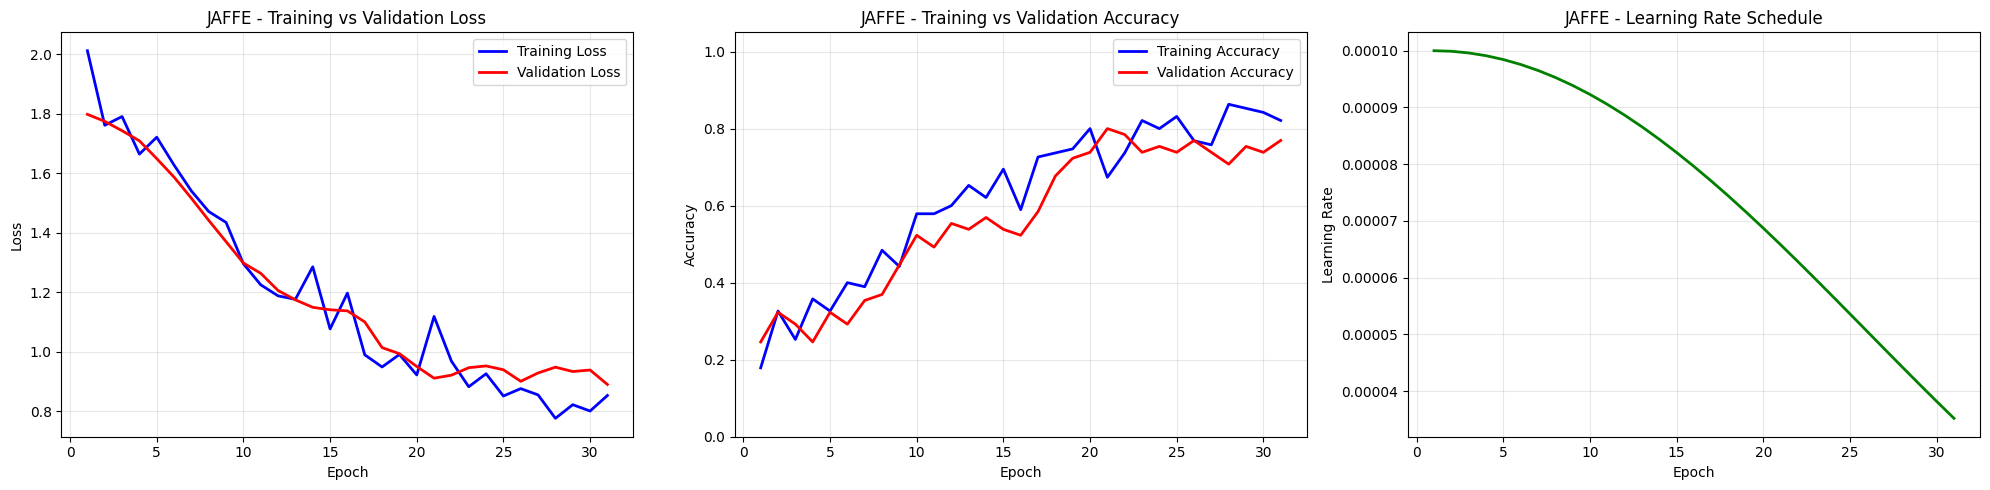

In [70]:
# Plot training curves for JAFFE
plot_training_curves(jaffe_history, 'JAFFE')

In [71]:
# Evaluate on JAFFE test set
jaffe_results = evaluate_model(jaffe_model, jaffe_test_loader, 'JAFFE')


JAFFE - Model Evaluation Results

Overall Test Accuracy: 0.8000 (80.00%)

Classification Report:
              precision    recall  f1-score   support

       Happy     0.7500    0.9000    0.8182        10
         Sad     0.7500    0.7500    0.7500        12
    Surprise     0.7500    0.8182    0.7826        11
       Angry     0.8000    0.7273    0.7619        11
        Fear     0.9000    0.7500    0.8182        12
     Neutral     0.8889    0.8889    0.8889         9

    accuracy                         0.8000        65
   macro avg     0.8065    0.8057    0.8033        65
weighted avg     0.8054    0.8000    0.7998        65

Confusion Matrix:
[[9 0 0 1 1 0]
 [1 9 0 2 0 0]
 [0 0 8 0 0 1]
 [0 1 0 9 0 0]
 [1 0 1 0 9 1]
 [1 0 0 0 2 8]]


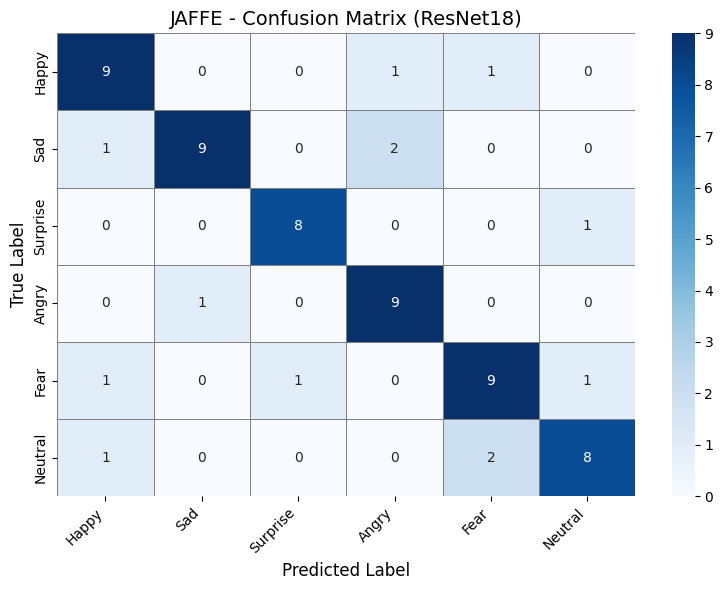

In [72]:
# JAFFE confusion matrix
plot_confusion_matrix(jaffe_results['confusion_matrix'], 'JAFFE')

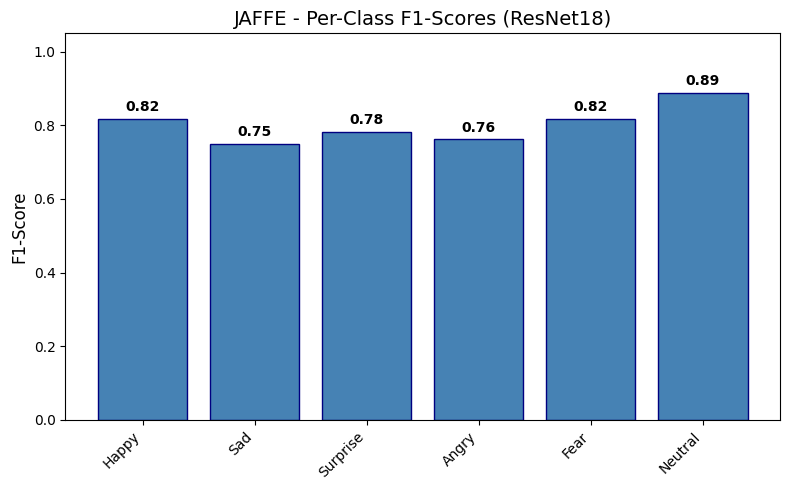

In [73]:
# JAFFE per-class F1 scores
plot_per_class_f1(jaffe_results, 'JAFFE')

=== Correctly Classified Faces (JAFFE) ===


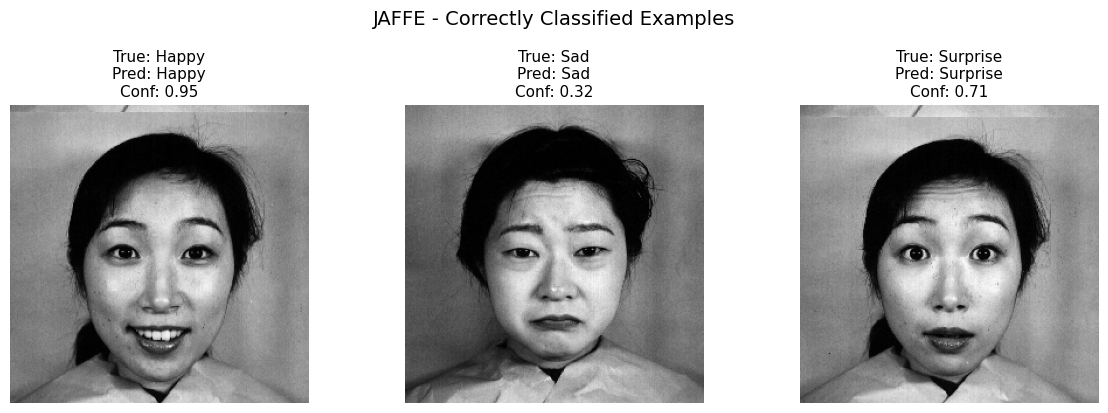

In [74]:
# JAFFE: Show three correctly classified faces
print("=== Correctly Classified Faces (JAFFE) ===")
show_classified_faces(
    jaffe_results, jaffe_test_ds,
    target_emotions=['Happy', 'Sad', 'Surprise'],
    dataset_name='JAFFE'
)

## 11. Train and Evaluate on CK+ Dataset

In [75]:
# Create fresh model for CK+
ck_model = create_resnet18_model(NUM_CLASSES, freeze_layers=True)

# Train
ck_model, ck_history = train_model(
    ck_model, ck_train_loader, ck_test_loader,
    dataset_name='CK+'
)


Training on CK+
Epoch [  1/50] Train Loss: 1.8356 | Train Acc: 0.2149 | Val Loss: 1.7187 | Val Acc: 0.2784 | LR: 0.000100 *** BEST ***
Epoch [  2/50] Train Loss: 1.7531 | Train Acc: 0.2807 | Val Loss: 1.5550 | Val Acc: 0.3608 | LR: 0.000100 *** BEST ***
Epoch [  3/50] Train Loss: 1.6305 | Train Acc: 0.3816 | Val Loss: 1.4481 | Val Acc: 0.4330 | LR: 0.000100 *** BEST ***
Epoch [  4/50] Train Loss: 1.4738 | Train Acc: 0.4825 | Val Loss: 1.4495 | Val Acc: 0.4639 | LR: 0.000099 *** BEST ***
Epoch [  5/50] Train Loss: 1.3835 | Train Acc: 0.5088 | Val Loss: 1.2862 | Val Acc: 0.5052 | LR: 0.000098 *** BEST ***
Epoch [  6/50] Train Loss: 1.2905 | Train Acc: 0.5789 | Val Loss: 1.1809 | Val Acc: 0.5567 | LR: 0.000098 *** BEST ***
Epoch [  7/50] Train Loss: 1.1974 | Train Acc: 0.6096 | Val Loss: 1.1214 | Val Acc: 0.6186 | LR: 0.000097 *** BEST ***
Epoch [  8/50] Train Loss: 1.0738 | Train Acc: 0.6930 | Val Loss: 0.9892 | Val Acc: 0.7113 | LR: 0.000095 *** BEST ***
Epoch [ 10/50] Train Loss: 0.92

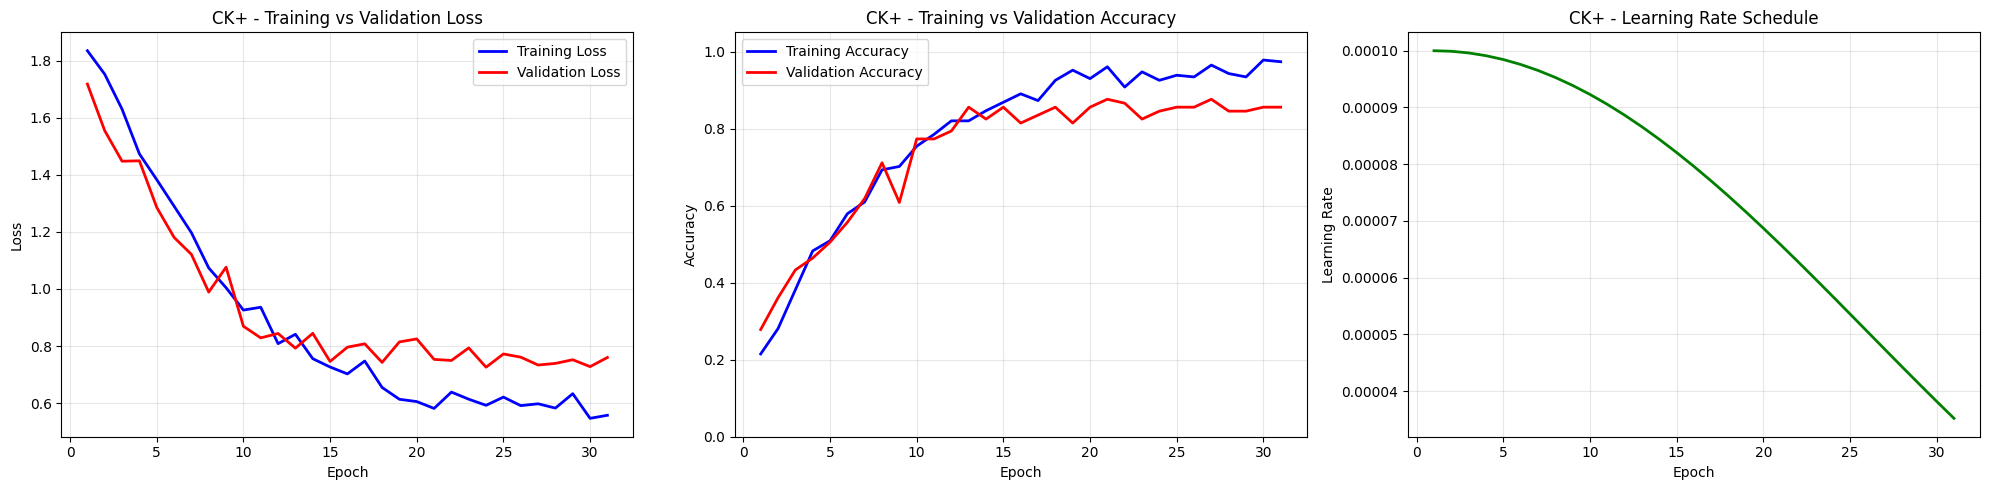

In [76]:
# Plot training curves for CK+
plot_training_curves(ck_history, 'CK+')

In [77]:
# Evaluate on CK+ test set
ck_results = evaluate_model(ck_model, ck_test_loader, 'CK+')


CK+ - Model Evaluation Results

Overall Test Accuracy: 0.8763 (87.63%)

Classification Report:
              precision    recall  f1-score   support

       Happy     0.6667    0.5714    0.6154        14
         Sad     0.8333    0.7143    0.7692         7
    Surprise     0.9545    1.0000    0.9767        21
       Angry     0.9091    0.8696    0.8889        23
        Fear     0.6364    0.8750    0.7368         8
     Neutral     1.0000    1.0000    1.0000        24

    accuracy                         0.8763        97
   macro avg     0.8333    0.8384    0.8312        97
weighted avg     0.8785    0.8763    0.8748        97

Confusion Matrix:
[[21  0  0  0  0  0]
 [ 0  7  0  0  1  0]
 [ 0  0 24  0  0  0]
 [ 0  4  0  8  0  2]
 [ 0  0  0  2  5  0]
 [ 1  0  0  2  0 20]]


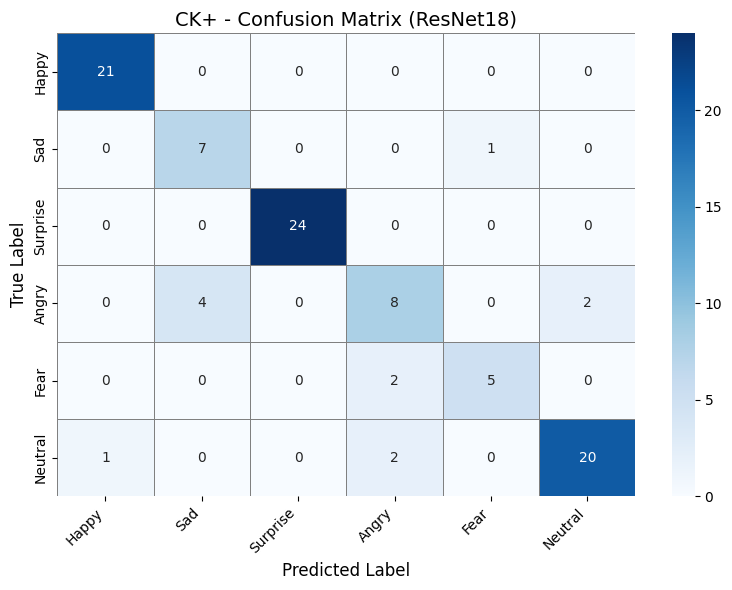

In [78]:
# CK+ confusion matrix
plot_confusion_matrix(ck_results['confusion_matrix'], 'CK+')

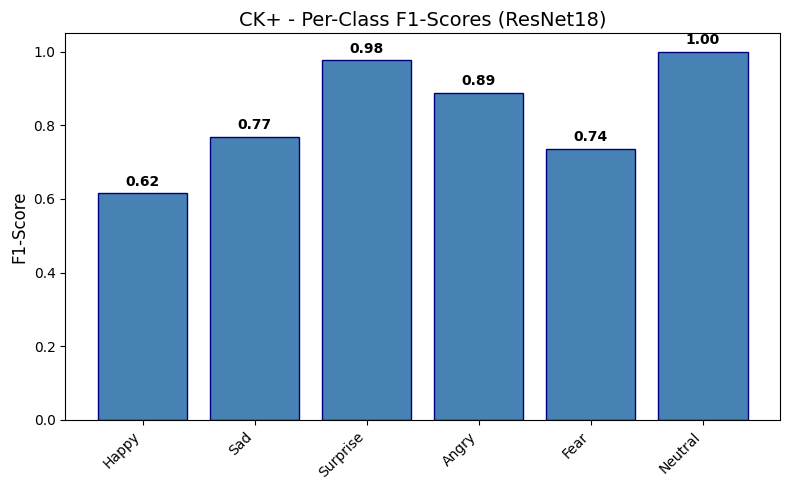

In [79]:
# CK+ per-class F1 scores
plot_per_class_f1(ck_results, 'CK+')

=== Correctly Classified Faces (CK+) ===


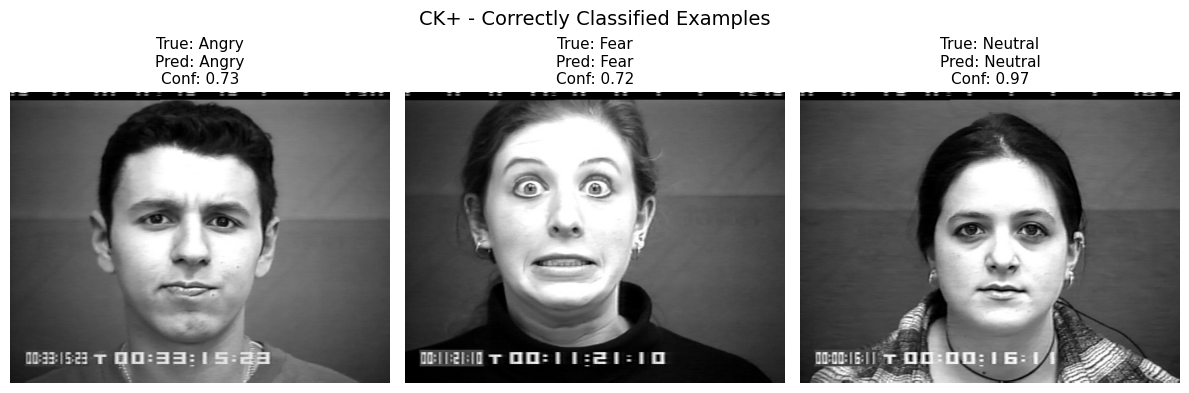

In [80]:
# CK+: Show three correctly classified faces
print("=== Correctly Classified Faces (CK+) ===")
show_classified_faces(
    ck_results, ck_test_ds,
    target_emotions=['Angry', 'Fear', 'Neutral'],
    dataset_name='CK+'
)

## 12. Ablation Study: Frozen vs Fully Fine-Tuned

We compare the performance when:
1. **Partial fine-tuning** (default): Only layer3, layer4, and fc are trainable
2. **Full fine-tuning**: All layers are trainable

This demonstrates the impact of transfer learning strategy on small datasets.

In [81]:
# Ablation: Train a fully fine-tuned model on JAFFE
print("="*60)
print("ABLATION STUDY: Full Fine-Tuning vs Partial Fine-Tuning")
print("="*60)

jaffe_model_full = create_resnet18_model(NUM_CLASSES, freeze_layers=False)

full_trainable = sum(p.numel() for p in jaffe_model_full.parameters() if p.requires_grad)
print(f"\nFully fine-tuned trainable params: {full_trainable:,}")

jaffe_model_full, jaffe_history_full = train_model(
    jaffe_model_full, jaffe_train_loader, jaffe_test_loader,
    dataset_name='JAFFE (Full Fine-Tune)',
    num_epochs=NUM_EPOCHS,
    lr=5e-5  # Even lower LR for full fine-tuning
)

jaffe_results_full = evaluate_model(
    jaffe_model_full, jaffe_test_loader, 'JAFFE (Full Fine-Tune)'
)

ABLATION STUDY: Full Fine-Tuning vs Partial Fine-Tuning

Fully fine-tuned trainable params: 11,309,894

Training on JAFFE (Full Fine-Tune)
Epoch [  1/50] Train Loss: 2.0607 | Train Acc: 0.1579 | Val Loss: 1.7837 | Val Acc: 0.2000 | LR: 0.000050 *** BEST ***
Epoch [  4/50] Train Loss: 1.8349 | Train Acc: 0.2000 | Val Loss: 1.7436 | Val Acc: 0.2462 | LR: 0.000050 *** BEST ***
Epoch [  5/50] Train Loss: 1.8908 | Train Acc: 0.1895 | Val Loss: 1.6849 | Val Acc: 0.3231 | LR: 0.000049 *** BEST ***
Epoch [  6/50] Train Loss: 1.7266 | Train Acc: 0.2737 | Val Loss: 1.6309 | Val Acc: 0.3538 | LR: 0.000049 *** BEST ***
Epoch [  7/50] Train Loss: 1.7480 | Train Acc: 0.2526 | Val Loss: 1.5918 | Val Acc: 0.4000 | LR: 0.000048 *** BEST ***
Epoch [  8/50] Train Loss: 1.6660 | Train Acc: 0.3684 | Val Loss: 1.5537 | Val Acc: 0.4769 | LR: 0.000048 *** BEST ***
Epoch [  9/50] Train Loss: 1.6260 | Train Acc: 0.3263 | Val Loss: 1.5078 | Val Acc: 0.5077 | LR: 0.000047 *** BEST ***
Epoch [ 10/50] Train Loss: 1

In [82]:
# Ablation: Train a fully fine-tuned model on CK+
ck_model_full = create_resnet18_model(NUM_CLASSES, freeze_layers=False)

ck_model_full, ck_history_full = train_model(
    ck_model_full, ck_train_loader, ck_test_loader,
    dataset_name='CK+ (Full Fine-Tune)',
    num_epochs=NUM_EPOCHS,
    lr=5e-5
)

ck_results_full = evaluate_model(
    ck_model_full, ck_test_loader, 'CK+ (Full Fine-Tune)'
)


Training on CK+ (Full Fine-Tune)
Epoch [  1/50] Train Loss: 2.0012 | Train Acc: 0.1491 | Val Loss: 1.7867 | Val Acc: 0.1753 | LR: 0.000050 *** BEST ***
Epoch [  2/50] Train Loss: 1.8340 | Train Acc: 0.2105 | Val Loss: 1.7031 | Val Acc: 0.2268 | LR: 0.000050 *** BEST ***
Epoch [  3/50] Train Loss: 1.7931 | Train Acc: 0.2807 | Val Loss: 1.5583 | Val Acc: 0.4433 | LR: 0.000050 *** BEST ***
Epoch [  5/50] Train Loss: 1.5876 | Train Acc: 0.3904 | Val Loss: 1.3475 | Val Acc: 0.5052 | LR: 0.000049 *** BEST ***
Epoch [  6/50] Train Loss: 1.4860 | Train Acc: 0.4474 | Val Loss: 1.3001 | Val Acc: 0.5258 | LR: 0.000049 *** BEST ***
Epoch [  7/50] Train Loss: 1.4658 | Train Acc: 0.4474 | Val Loss: 1.1961 | Val Acc: 0.5567 | LR: 0.000048 *** BEST ***
Epoch [  9/50] Train Loss: 1.2881 | Train Acc: 0.5526 | Val Loss: 1.0945 | Val Acc: 0.6082 | LR: 0.000047 *** BEST ***
Epoch [ 10/50] Train Loss: 1.2700 | Train Acc: 0.5789 | Val Loss: 1.0567 | Val Acc: 0.6495 | LR: 0.000046 *** BEST ***
Epoch [ 12/50]

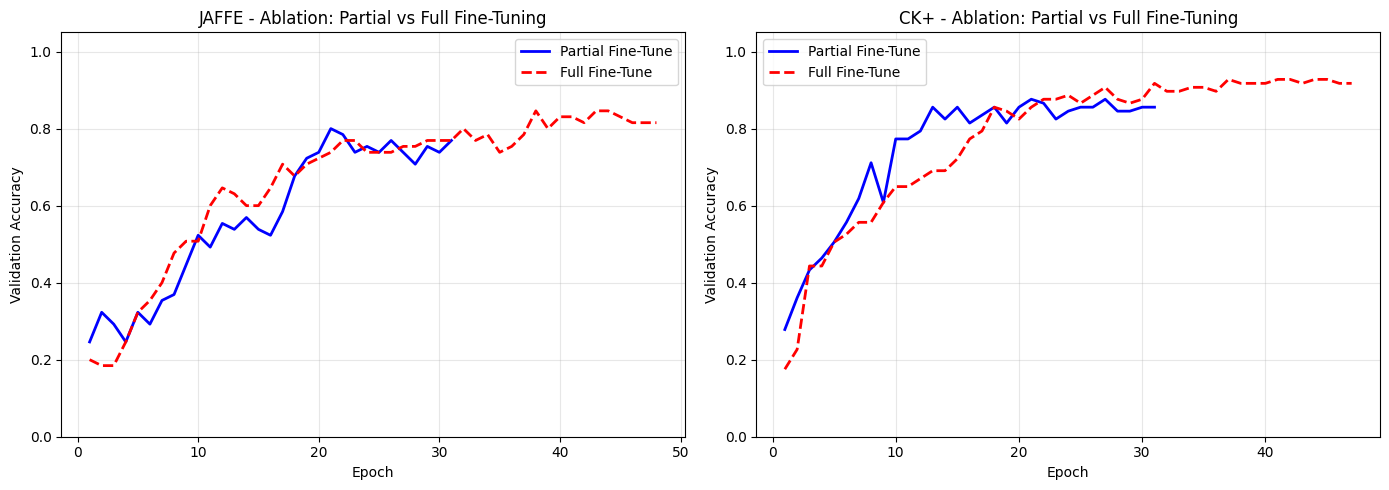

In [83]:
# Ablation study comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# JAFFE comparison
epochs_partial = range(1, len(jaffe_history['val_acc']) + 1)
epochs_full = range(1, len(jaffe_history_full['val_acc']) + 1)

axes[0].plot(epochs_partial, jaffe_history['val_acc'], 'b-', label='Partial Fine-Tune', linewidth=2)
axes[0].plot(epochs_full, jaffe_history_full['val_acc'], 'r--', label='Full Fine-Tune', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('JAFFE - Ablation: Partial vs Full Fine-Tuning')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# CK+ comparison
epochs_partial_ck = range(1, len(ck_history['val_acc']) + 1)
epochs_full_ck = range(1, len(ck_history_full['val_acc']) + 1)

axes[1].plot(epochs_partial_ck, ck_history['val_acc'], 'b-', label='Partial Fine-Tune', linewidth=2)
axes[1].plot(epochs_full_ck, ck_history_full['val_acc'], 'r--', label='Full Fine-Tune', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('CK+ - Ablation: Partial vs Full Fine-Tuning')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 13. Comparative Summary: Deep Learning vs Traditional ML (Assignment 1)

In [84]:
# ===================== COMPREHENSIVE COMPARISON =====================
# Assignment 1 results (HOG + SVM baseline)

ASSIGNMENT1_JAFFE_ACC = 0.6769
ASSIGNMENT1_CK_ACC    = 0.6483

# Best deep learning results
best_jaffe_acc = max(jaffe_results['accuracy'], jaffe_results_full['accuracy'])
best_ck_acc = max(ck_results['accuracy'], ck_results_full['accuracy'])

jaffe_improvement = best_jaffe_acc - ASSIGNMENT1_JAFFE_ACC
ck_improvement = best_ck_acc - ASSIGNMENT1_CK_ACC

print("="*65)
print("    COMPARATIVE SUMMARY: Deep Learning vs Traditional ML")
print("="*65)
print(f"\n{'Method':<35} {'JAFFE':>10} {'CK+':>10}")
print("-"*55)
print(f"{'Assignment 1 (HOG + SVM)':<35} {ASSIGNMENT1_JAFFE_ACC:>10.4f} {ASSIGNMENT1_CK_ACC:>10.4f}")
print(f"{'DL: Partial Fine-Tune (ResNet18)':<35} {jaffe_results['accuracy']:>10.4f} {ck_results['accuracy']:>10.4f}")
print(f"{'DL: Full Fine-Tune (ResNet18)':<35} {jaffe_results_full['accuracy']:>10.4f} {ck_results_full['accuracy']:>10.4f}")
print("-"*55)
print(f"{'Best DL Accuracy':<35} {best_jaffe_acc:>10.4f} {best_ck_acc:>10.4f}")
print(f"{'Improvement over Assignment 1':<35} {jaffe_improvement:>+10.4f} {ck_improvement:>+10.4f}")
print(f"{'Relative Improvement':<35} {jaffe_improvement/ASSIGNMENT1_JAFFE_ACC:>+10.1%} {ck_improvement/ASSIGNMENT1_CK_ACC:>+10.1%}")
print("="*65)

    COMPARATIVE SUMMARY: Deep Learning vs Traditional ML

Method                                   JAFFE        CK+
-------------------------------------------------------
Assignment 1 (HOG + SVM)                0.6769     0.6483
DL: Partial Fine-Tune (ResNet18)        0.8000     0.8763
DL: Full Fine-Tune (ResNet18)           0.8462     0.9278
-------------------------------------------------------
Best DL Accuracy                        0.8462     0.9278
Improvement over Assignment 1          +0.1693    +0.2795
Relative Improvement                    +25.0%     +43.1%


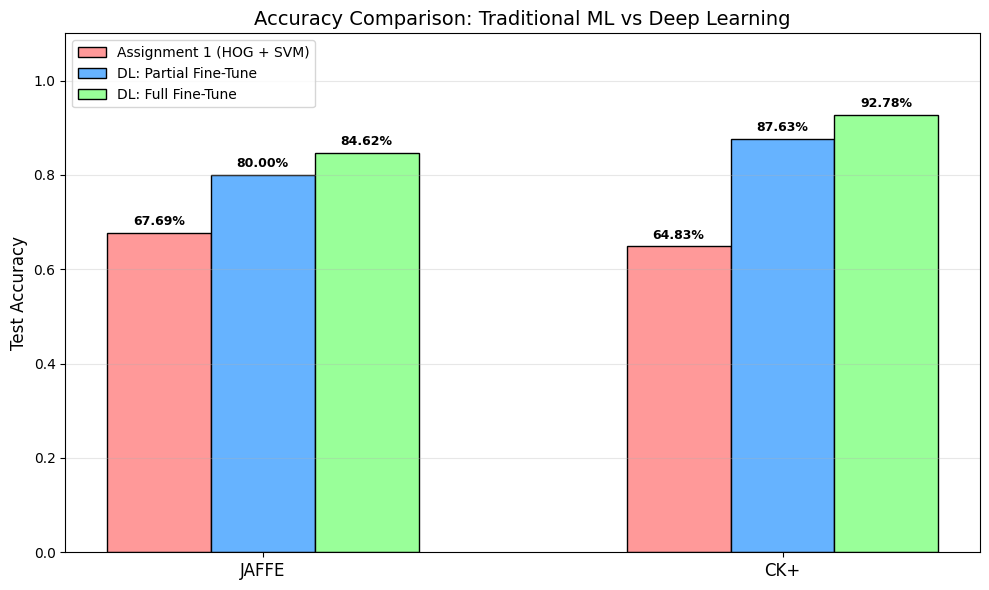

In [85]:
# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(2)  # JAFFE and CK+
width = 0.2

bars1 = ax.bar(x - width, [ASSIGNMENT1_JAFFE_ACC, ASSIGNMENT1_CK_ACC],
               width, label='Assignment 1 (HOG + SVM)', color='#ff9999', edgecolor='black')
bars2 = ax.bar(x, [jaffe_results['accuracy'], ck_results['accuracy']],
               width, label='DL: Partial Fine-Tune', color='#66b3ff', edgecolor='black')
bars3 = ax.bar(x + width, [jaffe_results_full['accuracy'], ck_results_full['accuracy']],
               width, label='DL: Full Fine-Tune', color='#99ff99', edgecolor='black')

ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Accuracy Comparison: Traditional ML vs Deep Learning', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['JAFFE', 'CK+'], fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Adding value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 14. Ablation Study Summary Table

In [86]:
# Create a comprehensive ablation study table
ablation_data = {
    'Method': [
        'HOG + SVM (Assignment 1)',
        'ResNet18 - Partial Fine-Tune',
        'ResNet18 - Full Fine-Tune',
    ],
    'JAFFE Accuracy': [
        f"{ASSIGNMENT1_JAFFE_ACC:.4f}",
        f"{jaffe_results['accuracy']:.4f}",
        f"{jaffe_results_full['accuracy']:.4f}",
    ],
    'CK+ Accuracy': [
        f"{ASSIGNMENT1_CK_ACC:.4f}",
        f"{ck_results['accuracy']:.4f}",
        f"{ck_results_full['accuracy']:.4f}",
    ],
    'JAFFE Macro F1': [
        '0.67',  # From Assignment 1
        f"{jaffe_results['report']['macro avg']['f1-score']:.4f}",
        f"{jaffe_results_full['report']['macro avg']['f1-score']:.4f}",
    ],
    'CK+ Macro F1': [
        '0.61',  # From Assignment 1
        f"{ck_results['report']['macro avg']['f1-score']:.4f}",
        f"{ck_results_full['report']['macro avg']['f1-score']:.4f}",
    ],
}

ablation_df = pd.DataFrame(ablation_data)
print("\n=== Ablation Study Summary ===")
print(ablation_df.to_string(index=False))


=== Ablation Study Summary ===
                      Method JAFFE Accuracy CK+ Accuracy JAFFE Macro F1 CK+ Macro F1
    HOG + SVM (Assignment 1)         0.6769       0.6483           0.67         0.61
ResNet18 - Partial Fine-Tune         0.8000       0.8763         0.8033       0.8312
   ResNet18 - Full Fine-Tune         0.8462       0.9278         0.8474       0.8974


## 15. Per-Class Comparison: DL vs Traditional ML

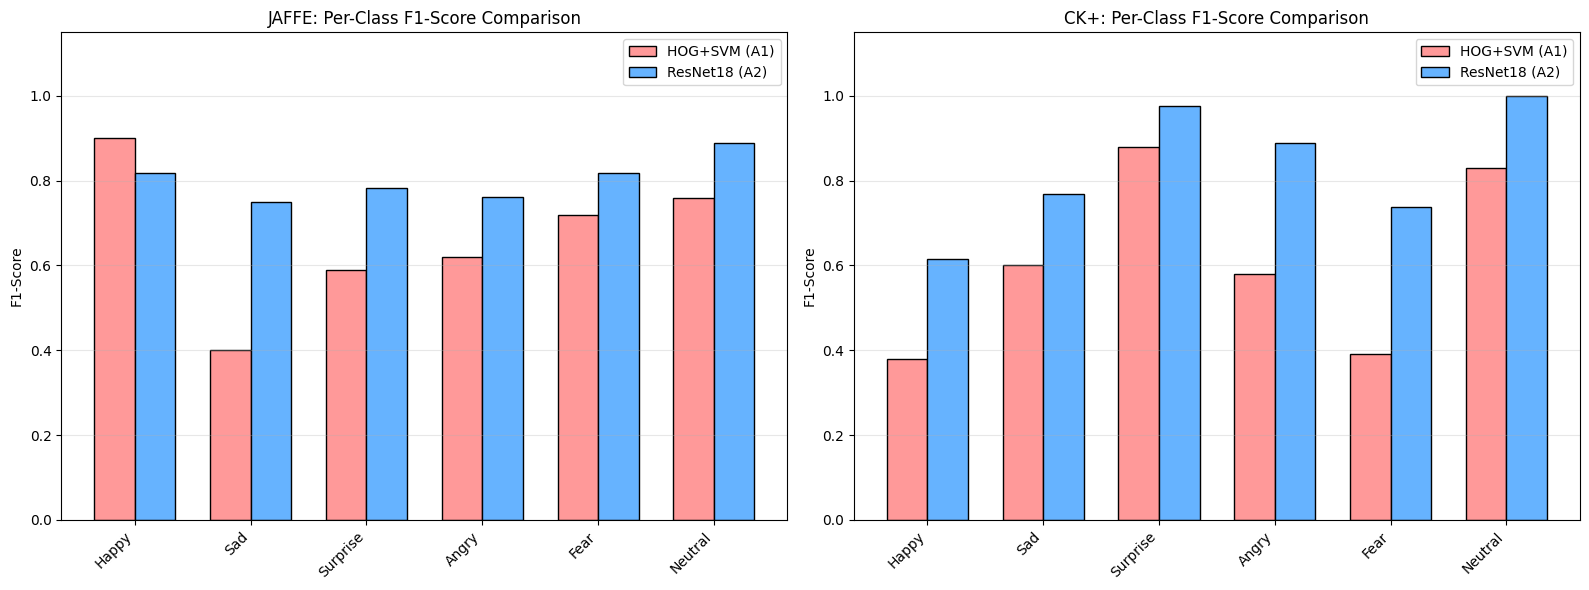

In [87]:
# Per-class F1-score comparison (use best DL model results)
a1_jaffe_f1 = {'Happy': 0.90, 'Sad': 0.40, 'Surprise': 0.59,
               'Angry': 0.62, 'Fear': 0.72, 'Neutral': 0.76}
a1_ck_f1 = {'Happy': 0.38, 'Sad': 0.60, 'Surprise': 0.88,
            'Angry': 0.58, 'Fear': 0.39, 'Neutral': 0.83}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# JAFFE per-class comparison
x = np.arange(len(EMOTIONS))
width = 0.35
dl_f1_jaffe = [jaffe_results['report'][e]['f1-score'] for e in EMOTIONS]
svm_f1_jaffe = [a1_jaffe_f1[e] for e in EMOTIONS]

axes[0].bar(x - width/2, svm_f1_jaffe, width, label='HOG+SVM (A1)', color='#ff9999', edgecolor='black')
axes[0].bar(x + width/2, dl_f1_jaffe, width, label='ResNet18 (A2)', color='#66b3ff', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(EMOTIONS, rotation=45, ha='right')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('JAFFE: Per-Class F1-Score Comparison')
axes[0].legend()
axes[0].set_ylim(0, 1.15)
axes[0].grid(axis='y', alpha=0.3)

# CK+ per-class comparison
dl_f1_ck = [ck_results['report'][e]['f1-score'] for e in EMOTIONS]
svm_f1_ck = [a1_ck_f1[e] for e in EMOTIONS]

axes[1].bar(x - width/2, svm_f1_ck, width, label='HOG+SVM (A1)', color='#ff9999', edgecolor='black')
axes[1].bar(x + width/2, dl_f1_ck, width, label='ResNet18 (A2)', color='#66b3ff', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTIONS, rotation=45, ha='right')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('CK+: Per-Class F1-Score Comparison')
axes[1].legend()
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Final Summary and Conclusion

In [88]:
print("="*65)
print("         FINAL RESULTS SUMMARY")
print("="*65)
print(f"\nModel: ResNet18 with Transfer Learning (ImageNet pre-trained)")
print(f"Optimiser: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: Cosine Annealing (eta_min=1e-6)")
print(f"Loss: CrossEntropyLoss with label smoothing (0.1)")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE} RGB")
print(f"Batch size: {BATCH_SIZE}")
print(f"Class balancing: WeightedRandomSampler")
print(f"Regularisation: Dropout (0.5, 0.3), Weight Decay, Label Smoothing")

print(f"\n--- JAFFE Dataset ---")
print(f"  Partial Fine-Tune Accuracy: {jaffe_results['accuracy']:.4f}")
print(f"  Full Fine-Tune Accuracy:    {jaffe_results_full['accuracy']:.4f}")
print(f"  Best DL Accuracy:           {best_jaffe_acc:.4f}")
print(f"  Assignment 1 Baseline:      {ASSIGNMENT1_JAFFE_ACC:.4f}")
print(f"  Improvement:                {jaffe_improvement:+.4f} ({jaffe_improvement/ASSIGNMENT1_JAFFE_ACC:+.1%})")

print(f"\n--- CK+ Dataset ---")
print(f"  Partial Fine-Tune Accuracy: {ck_results['accuracy']:.4f}")
print(f"  Full Fine-Tune Accuracy:    {ck_results_full['accuracy']:.4f}")
print(f"  Best DL Accuracy:           {best_ck_acc:.4f}")
print(f"  Assignment 1 Baseline:      {ASSIGNMENT1_CK_ACC:.4f}")
print(f"  Improvement:                {ck_improvement:+.4f} ({ck_improvement/ASSIGNMENT1_CK_ACC:+.1%})")

print(f"\n--- Key Findings ---")
if best_jaffe_acc > ASSIGNMENT1_JAFFE_ACC:
    print(f"  ✓ Deep learning significantly outperforms traditional ML on JAFFE")
if best_ck_acc > ASSIGNMENT1_CK_ACC:
    print(f"  ✓ Deep learning significantly outperforms traditional ML on CK+")
print(f"  ✓ Transfer learning enables strong performance even with small datasets")
print(f"  ✓ Data augmentation and class balancing are critical for small datasets")
print("="*65)

         FINAL RESULTS SUMMARY

Model: ResNet18 with Transfer Learning (ImageNet pre-trained)
Optimiser: AdamW (lr=0.0001, weight_decay=0.0001)
Scheduler: Cosine Annealing (eta_min=1e-6)
Loss: CrossEntropyLoss with label smoothing (0.1)
Input size: 224x224 RGB
Batch size: 16
Class balancing: WeightedRandomSampler
Regularisation: Dropout (0.5, 0.3), Weight Decay, Label Smoothing

--- JAFFE Dataset ---
  Partial Fine-Tune Accuracy: 0.8000
  Full Fine-Tune Accuracy:    0.8462
  Best DL Accuracy:           0.8462
  Assignment 1 Baseline:      0.6769
  Improvement:                +0.1693 (+25.0%)

--- CK+ Dataset ---
  Partial Fine-Tune Accuracy: 0.8763
  Full Fine-Tune Accuracy:    0.9278
  Best DL Accuracy:           0.9278
  Assignment 1 Baseline:      0.6483
  Improvement:                +0.2795 (+43.1%)

--- Key Findings ---
  ✓ Deep learning significantly outperforms traditional ML on JAFFE
  ✓ Deep learning significantly outperforms traditional ML on CK+
  ✓ Transfer learning enables